✅ Datos cargados listos para graficar: 21188 pacientes.


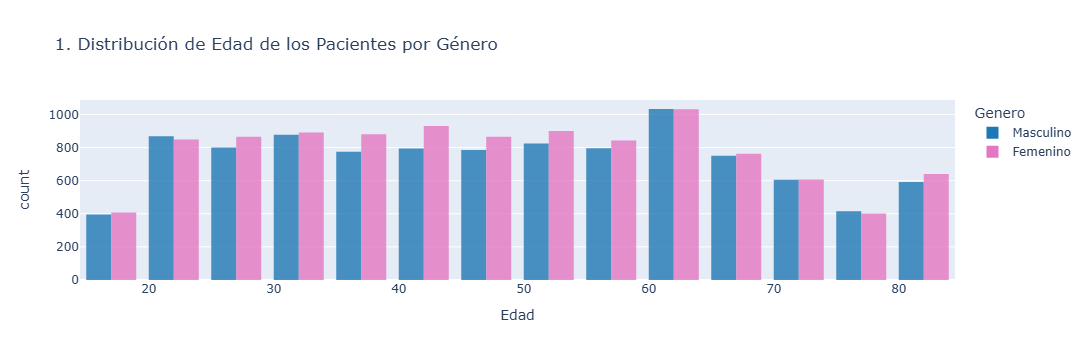

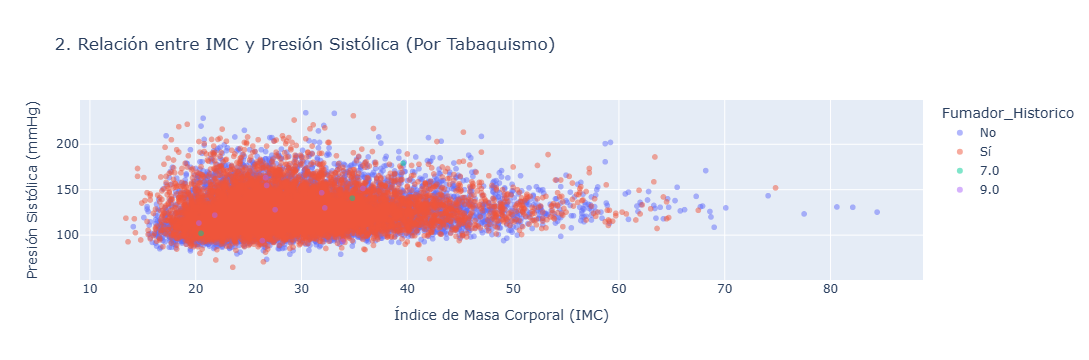

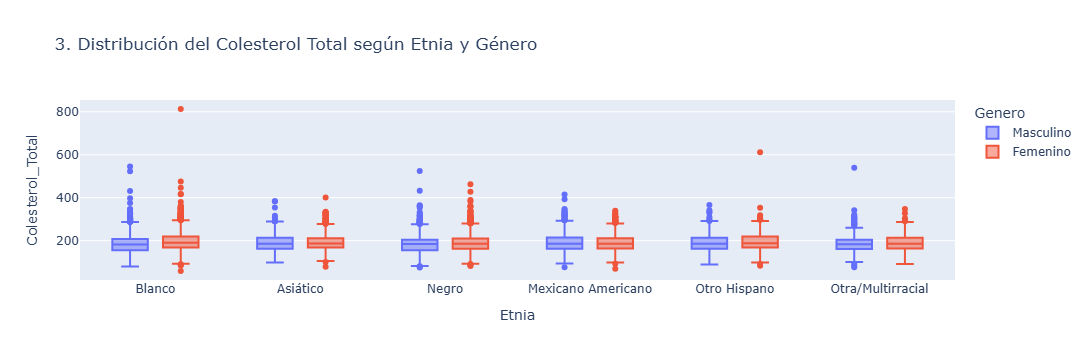

In [1]:
import pandas as pd
import plotly.express as px

# 1. Cargar tu obra de arte (el dataset limpio)
df = pd.read_csv("../data/02_intermediate/df_nhanes_adultos_limpio.csv")

print(f"✅ Datos cargados listos para graficar: {df.shape[0]} pacientes.")

# ==============================================================================
# GRÁFICO 1: Distribución de Edades por Género (Histograma)
# Nos sirve para ver cómo está compuesta nuestra población.
# ==============================================================================
fig1 = px.histogram(
    df, x="Edad", color="Genero", 
    nbins=20, barmode="group", opacity=0.8,
    color_discrete_map={"Masculino": "#1f77b4", "Femenino": "#e377c2"},
    title="1. Distribución de Edad de los Pacientes por Género"
)
fig1.show()

# ==============================================================================
# GRÁFICO 2: Relación entre IMC y Presión Sistólica (Dispersión)
# ¿A mayor peso, mayor presión arterial? Aquí lo descubriremos.
# ==============================================================================
fig2 = px.scatter(
    df, x="IMC", y="Presion_Sistolica", color="Fumador_Historico",
    opacity=0.5,
    title="2. Relación entre IMC y Presión Sistólica (Por Tabaquismo)",
    labels={"Presion_Sistolica": "Presión Sistólica (mmHg)", "IMC": "Índice de Masa Corporal (IMC)"}
)
fig2.show()

# ==============================================================================
# GRÁFICO 3: Distribución del Colesterol por Etnia (Cajas / Boxplot)
# Excelente para ver promedios y valores atípicos (outliers).
# ==============================================================================
fig3 = px.box(
    df, x="Etnia", y="Colesterol_Total", color="Genero",
    title="3. Distribución del Colesterol Total según Etnia y Género"
)
fig3.show()

✅ Intrusos eliminados. Pacientes listos: 21175


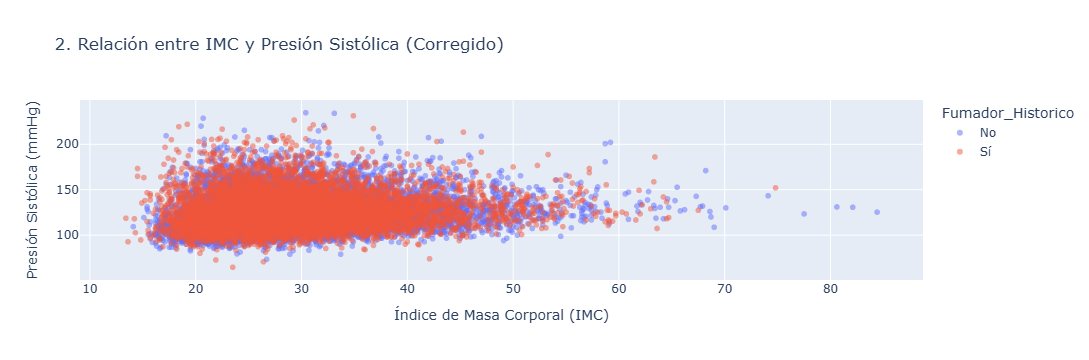

In [2]:
# 1. Dejar solo a los que respondieron claramente "Sí" o "No"
df = df[df['Fumador_Historico'].isin(['Sí', 'No'])].copy()

print(f"✅ Intrusos eliminados. Pacientes listos: {df.shape[0]}")

# 2. Volver a graficar sin la basura
fig2_corregido = px.scatter(
    df, x="IMC", y="Presion_Sistolica", color="Fumador_Historico",
    opacity=0.5,
    title="2. Relación entre IMC y Presión Sistólica (Corregido)",
    labels={"Presion_Sistolica": "Presión Sistólica (mmHg)", "IMC": "Índice de Masa Corporal (IMC)"}
)
fig2_corregido.show()

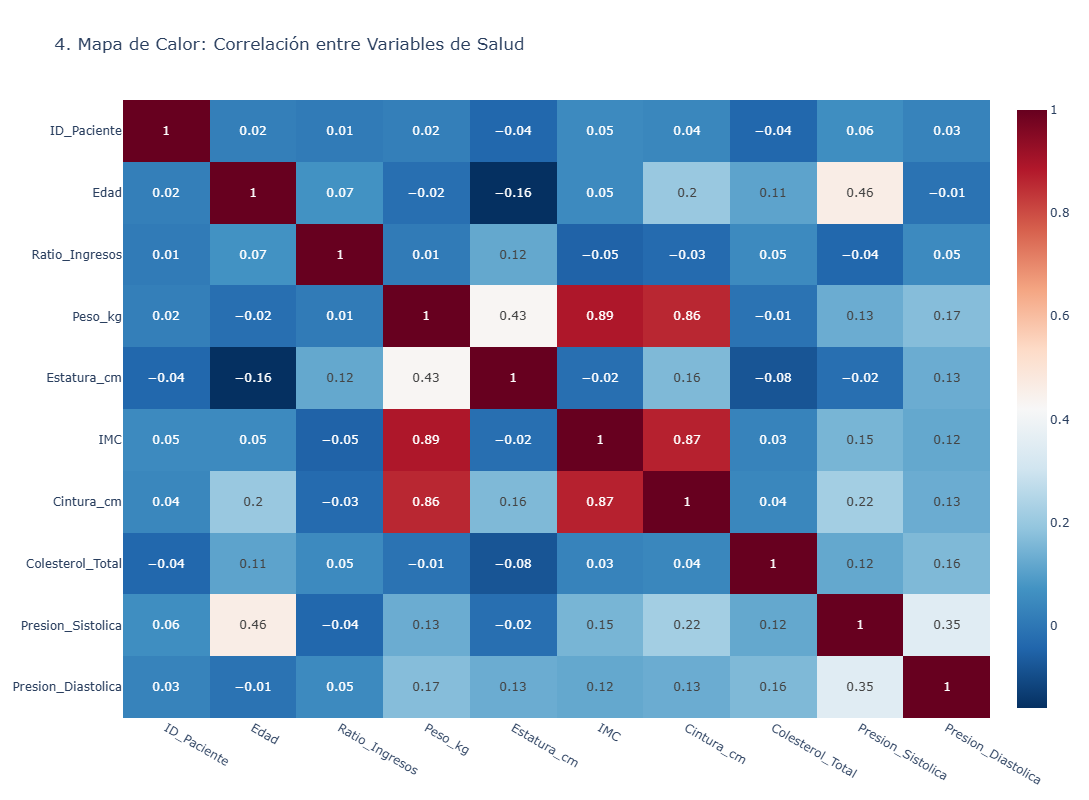

In [3]:
# 1. Filtrar solo las columnas numéricas (la matemática no funciona con texto)
columnas_numericas = df.select_dtypes(include=['float64', 'int64'])

# 2. Calcular la matriz de correlación de Pearson
matriz_corr = columnas_numericas.corr().round(2)

# 3. Graficar el Mapa de Calor (Heatmap) con Plotly
fig_corr = px.imshow(
    matriz_corr,
    text_auto=True, # Muestra los números dentro de los cuadros
    aspect="auto",
    color_continuous_scale='RdBu_r', # Rojo para correlación positiva, Azul para negativa
    title="4. Mapa de Calor: Correlación entre Variables de Salud"
)

# Ajustar un poco el tamaño para que se lea mejor
fig_corr.update_layout(width=900, height=800)
fig_corr.show()